# Module 4 · Lab 4.2 — Conversational RAG: Memory, Compression & Persistence
## Give your RAG assistant a memory — per user, bounded, cacheable, and resumable

---

### Lab overview

Lab 4.1 built a RAG system that answers **one question at a time**. Real assistants hold a
**conversation**: they remember what each user already asked, resolve follow-ups like *"and what
about its fees?"*, keep separate threads for separate users, stay affordable as the chat grows,
and survive a restart. This lab adds all of that on top of the Lab 4.1 pipeline.

| Part | You will build |
|---|---|
| **A · Memory** | A conversational RAG chain with **per-user threads** (one message list per user, injected via `MessagesPlaceholder`), history-aware follow-ups, and `RunnableParallel` returning **answer + sources + citations** |
| **B · Compression** | Five ways to shrink a growing history — **full / window / token-budget / summary / summary-buffer** — with a **decision matrix** for choosing |
| **C · Caching** | **OpenAI prompt caching** over the stable system+context prefix, and how it interacts with compression |
| **D · Persistence** | **Save** every user's conversation to JSON and **resume** it later |

### Learning objectives
1. Wire a per-user memory store into a RAG chain — one message list per `user_id`, injected through a **`MessagesPlaceholder`**
2. Reformulate follow-up questions into standalone queries so retrieval still works mid-conversation
3. Compress history with core **`trim_messages`** and **LCEL summary chains** — and know which to use when
4. Observe **OpenAI prompt caching** and reason about the caching ↔ compression trade-off
5. **Persist** conversations to JSON and **resume** them (`messages_to_dict` / `messages_from_dict`)

### Prerequisites
- `OPENAI_API_KEY` · the workshop VM, Colab, or a local `.env` · Lab 3.1, Lab 3.2 and Lab 4.1
- The `./docs` banking corpus next to this notebook (the same files as Lab 4.1 and Lab 7.4)

> **Everything is pure LCEL** — every prompt is a `ChatPromptTemplate`, every chain is
> `prompt | chat_model | StrOutputParser()` wired with `RunnableParallel` / `RunnablePassthrough`.
> No deprecated memory classes: `ConversationBufferMemory` & friends are avoided by design, and so is
> `RunnableWithMessageHistory`, whose chat-history store is deprecated from langchain-core 1.6.4.

> 🗺️ **Workshop run-list.**
> **Live in session:** §1–8 (corpus, two prompts, the conversational chain, per-user threads, a follow-up that needs memory ⭐), Part B §9–12 (five ways to compress a growing history, and when to use which), Part D §15–16 (persist and resume), §17
> **After the session:** Part C §13–14 OpenAI prompt caching, and its trade-off with compression — kept in full so you can finish at your own pace (marked ⏭️).

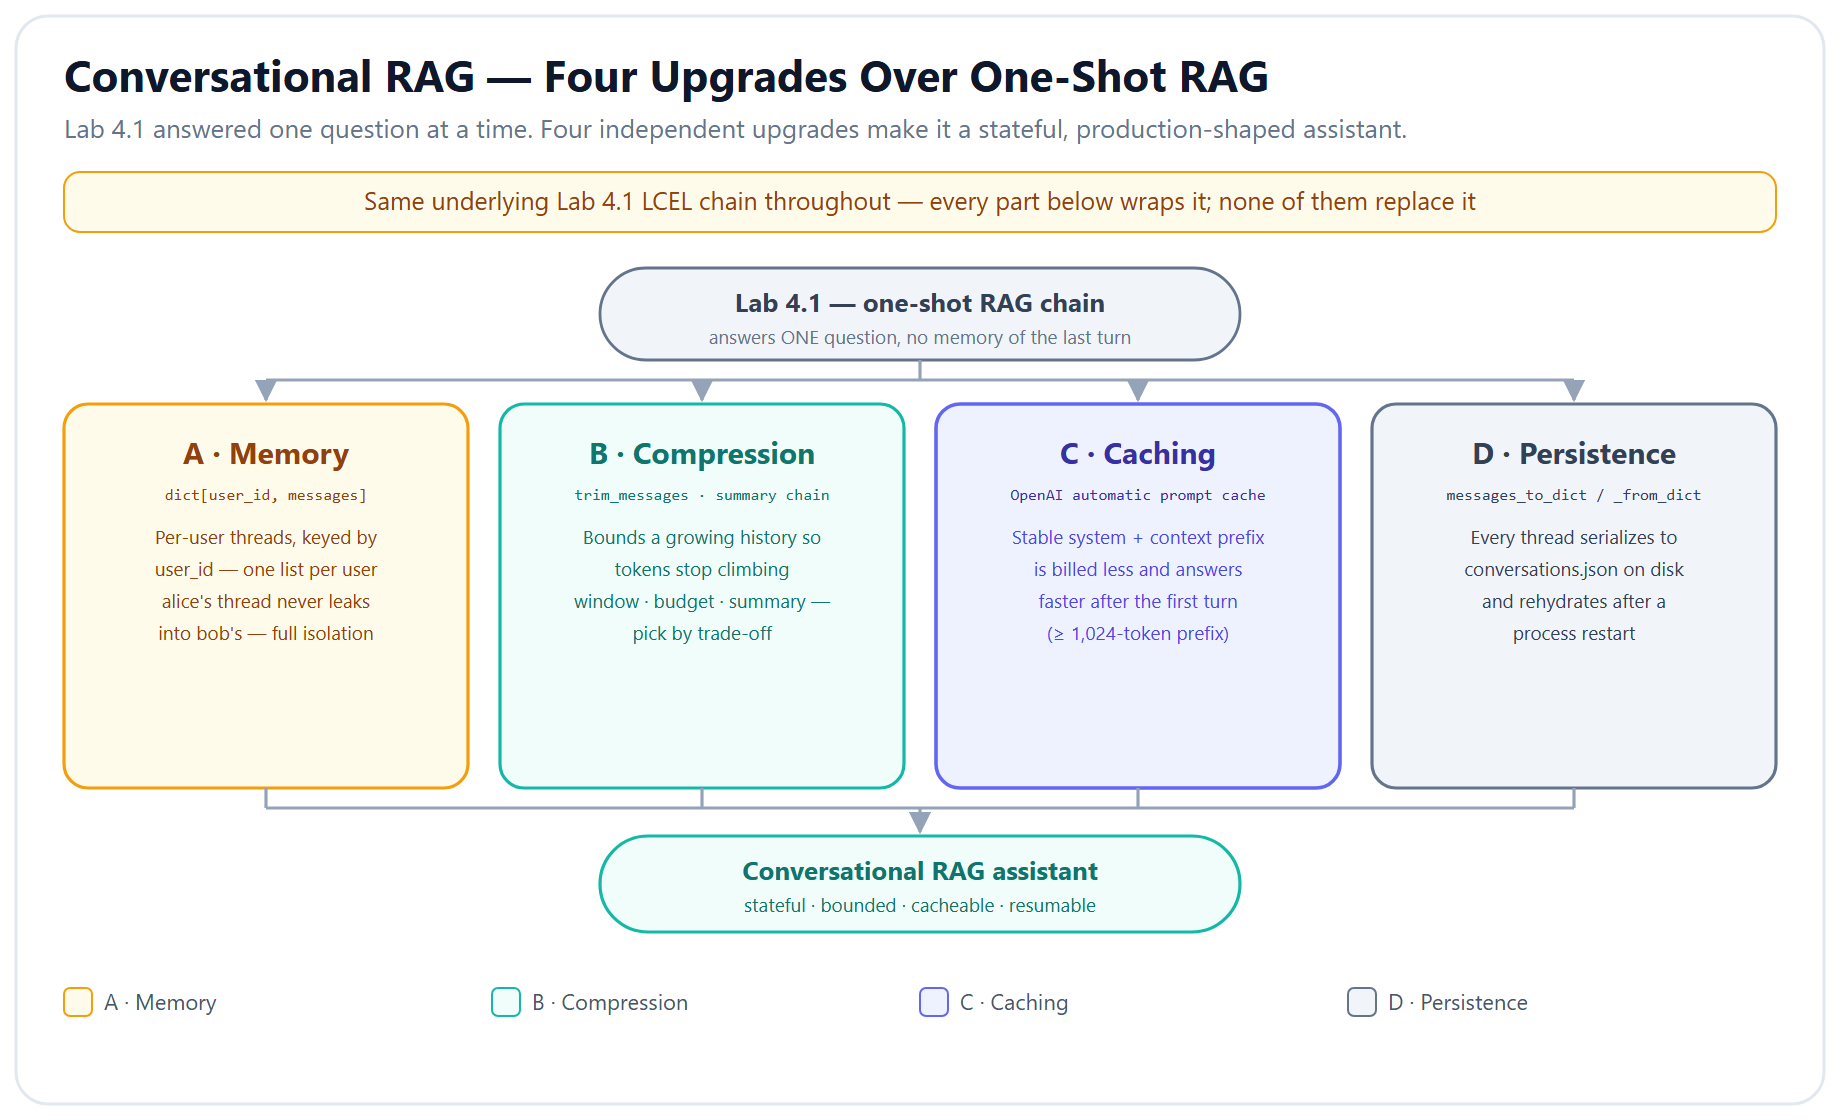

**Figure — Four upgrades over one-shot RAG.** On top of Lab 4.1's pipeline this lab adds per-user Memory (A), history Compression (B), prompt Caching (C), and JSON Persistence (D) — the shape of a real production chatbot.

## 1. Setup — install dependencies

In [1]:
# 📦 Packages this notebook needs. On the workshop VM they are pre-installed from
# the workshop's requirements.txt, so the install line below stays commented out.
# Running somewhere else (Colab, your own laptop)? Uncomment it and run this cell once.
# !pip install -qU faiss-cpu langchain langchain-community langchain-core langchain-openai langchain-text-splitters python-dotenv

from importlib.metadata import PackageNotFoundError, version

NOTEBOOK_PACKAGES = [
    "faiss-cpu",
    "langchain",
    "langchain-community",
    "langchain-core",
    "langchain-openai",
    "langchain-text-splitters",
    "python-dotenv",
]
for package_name in NOTEBOOK_PACKAGES:
    try:
        print(f"{package_name:<26} {version(package_name)}")
    except PackageNotFoundError:
        print(f"{package_name:<26} NOT INSTALLED — uncomment the !pip line above")

faiss-cpu                  1.15.1
langchain                  1.4.3
langchain-community        0.4.2
langchain-core             1.6.6
langchain-openai           1.6.6
langchain-text-splitters   1.1.2
python-dotenv              1.2.3


> ⚠️ **One expected warning.** The first cell that imports from `langchain_community` prints a
> `DeprecationWarning` saying the package *"is being sunset"*. LangChain stopped maintaining its
> community-integrations package in May 2026. The classes this lab uses from it — `DirectoryLoader`, `FAISS`, `TextLoader` —
> have no maintained LangChain replacement yet, so the workshop keeps them, pinned at the version
> tested here (0.4.2): the code works as shown. Integrations that did move to their own packages
> are imported from those — Chroma from `langchain-chroma`, Tavily from `langchain-tavily`.

## 2. Load your API key

In [2]:
import os

# Where to create each key. The trainer supplies OPENAI_API_KEY on the workshop VM;
# you create any other key yourself and add it to the workshop's .env file as KEY_NAME=value.
KEY_SIGNUP_PAGES = {
    "OPENAI_API_KEY": "supplied on the workshop VM (elsewhere: https://platform.openai.com/api-keys)",
    "TAVILY_API_KEY": "https://app.tavily.com (free tier)",
    "GROQ_API_KEY": "https://console.groq.com/keys (free tier)",
    "WEATHER_API_KEY": "https://www.weatherapi.com/signup.aspx (free tier)",
    "LANGSMITH_API_KEY": "https://smith.langchain.com -> Settings -> API Keys (free tier)",
    "ANTHROPIC_API_KEY": "https://console.anthropic.com/settings/keys",
    "GEMINI_API_KEY": "https://aistudio.google.com/app/apikey",
}


def load_keys(required):
    """Load API keys from Colab Secrets (on Colab) or a local .env file (elsewhere).

    Prints one line per key, then stops with instructions if a required key is missing.

    Args:
        required: the environment-variable names this lab needs.
    """
    try:
        from google.colab import userdata          # running on Google Colab
        for key_name in required:
            try:
                os.environ[key_name] = userdata.get(key_name)
            except Exception:
                pass                                 # not set in Colab Secrets
        source = "Colab Secrets"
    except ImportError:                              # the workshop VM, or any local machine
        from dotenv import find_dotenv, load_dotenv
        load_dotenv(find_dotenv(usecwd=True))        # searches upward for the workshop's .env file
        source = ".env / environment"
    print(f"\U0001F511 Key source: {source}")
    for key_name in required:
        print(f"   {key_name:<22} {'✅' if os.environ.get(key_name) else '❌ MISSING'}")
    missing_keys = [key_name for key_name in required if not os.environ.get(key_name)]
    if missing_keys:
        instructions = "\n".join(
            f"  {key_name}: {KEY_SIGNUP_PAGES.get(key_name, 'see README.md in the workshop folder')}"
            for key_name in missing_keys)
        raise RuntimeError(
            "This lab needs API keys that are not set yet. Create each one, add it to\n"
            "the workshop's .env file as KEY_NAME=value, then re-run this cell:\n" + instructions)

load_keys(["OPENAI_API_KEY"])

🔑 Key source: .env / environment
   OPENAI_API_KEY         ✅


## 3. Imports & the shared display helpers

The prompt, runnable and message pieces are all from **current** LangChain core modules — `trim_messages`
and the message (de)serialisers are supported core APIs. The per-user history is a plain **message
list** per user (§7 explains why). We also define the two canonical helpers reused across the RAG
labs of this workshop: `get_doc_signature` and `show_hits`.

In [3]:
import json
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import DirectoryLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableParallel, RunnablePassthrough, RunnableBranch
from langchain_core.messages import (AIMessage, HumanMessage, SystemMessage, messages_from_dict,
                                     messages_to_dict, trim_messages)
from IPython.display import display, Markdown

EMBED_MODEL = "text-embedding-3-small"   # 1536-dim (see Lab 3.2)
CHAT_MODEL  = "gpt-4.1-mini"             # fast, supports temperature, and auto prompt-caching

def get_doc_signature(document):
    """Return a short, human-readable label for a retrieved document.

    Uses the document's title when present, otherwise its source file name.
    """
    title = document.metadata.get("title")
    source = document.metadata.get("source", "unknown source")
    label = title or os.path.basename(str(source))
    return label[:44]

def show_hits(documents, label=""):
    """Print a numbered list of retrieved documents, each with a short preview."""
    if label:
        print(f"— {label} —")
    for position, document in enumerate(documents, start=1):
        preview = document.page_content[:70].strip()
        print(f"  {position}. [{get_doc_signature(document)}] {preview}…")

print("✅ Imports ready")

C:\Users\participant\AppData\Local\Temp\ipykernel_54004\2311148161.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


✅ Imports ready


## 4. Load the corpus & build the retriever (reuse `./docs`, no regeneration)

We load the **pre-provided** banking policy files from `./docs` — the same corpus as Lab 4.1 —
chunk them, embed with `text-embedding-3-small`, and index in FAISS. This is exactly the Lab 4.1
front end; the new material is everything the retriever feeds into.

In [4]:
assert os.path.isdir("docs"), "❌ Missing ./docs — the shared banking-policy corpus (same as Lab 4.1)."

loader = DirectoryLoader("docs", glob="*.md", loader_cls=TextLoader, loader_kwargs={"encoding": "utf-8"})
raw_documents = loader.load()
for document in raw_documents:
    file_name = os.path.basename(document.metadata["source"])
    document.metadata["title"] = file_name.removesuffix(".md").replace("_", " ").title()

splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(raw_documents)

embeddings = OpenAIEmbeddings(model=EMBED_MODEL)
chat_model = ChatOpenAI(model=CHAT_MODEL, temperature=0)   # temperature 0 → factual, repeatable
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

print(f"✅ {len(raw_documents)} documents → {len(chunks)} chunks → FAISS ({vector_store.index.ntotal} vectors)")

✅ 9 documents → 13 chunks → FAISS (13 vectors)


## 5. Two robust prompts — `ChatPromptTemplate` with a history slot

Conversational RAG needs **two** prompts, each with a `MessagesPlaceholder("chat_history")` so prior
turns flow in:

1. **Contextualize** — rewrites a follow-up ("*what about its fees?*") into a **standalone** question
   the retriever can search. It must *not* answer — only reformulate.
2. **Answer** — the grounded banking assistant: answer **only** from context, **cite `[doc N]`** after
   each claim, quote exact figures, and refuse when the corpus doesn't cover it.

We keep these deliberately detailed — a robust system prompt is the cheapest reliability win in RAG.

In [5]:
contextualize_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You reformulate a user's latest message into a COMPLETE, STANDALONE question for a banking "
     "knowledge-base search.\n"
     "- Use the conversation history to resolve every pronoun and reference (e.g. 'that account', "
     "'it', 'those fees') to the specific entity discussed earlier.\n"
     "- If the latest message is already self-contained, return it unchanged.\n"
     "- Do NOT answer the question and do NOT add commentary. Return ONLY the reformulated question."),
    MessagesPlaceholder("chat_history"),
    ("human", "{input}"),
])

answer_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are a precise, friendly banking-policy assistant. Answer the user's question using ONLY the "
     "context provided below — never outside knowledge.\n"
     "Guidelines:\n"
     "1. Quote exact figures (rates, fees, limits, scores, dates) whenever the context contains them.\n"
     "2. After each factual claim, cite its supporting source inline as [doc N], matching the numbered "
     "context blocks.\n"
     "3. Use the conversation history to interpret follow-up questions naturally, but ground every "
     "answer in the retrieved context.\n"
     "4. If the context does not contain the answer, say so plainly: "
     "\"I don't have that in the provided policy documents.\" Do not guess.\n"
     "5. Be concise and conversational."),
    MessagesPlaceholder("chat_history"),
    ("human", "Question: {input}\n\nContext:\n{context}\n\nAnswer:"),
])

contextualize_chain = contextualize_prompt | chat_model | StrOutputParser()
print("✅ Prompts + contextualize chain ready")

✅ Prompts + contextualize chain ready


## 6. The conversational RAG chain — `RunnableParallel` returns answer **and** sources

We assemble it in pure LCEL:
1. **Standalone question** — a `RunnableBranch`: skip reformulation on the first turn (no history yet),
   otherwise run the contextualize chain.
2. **Retrieve** the documents for that standalone question.
3. **`RunnableParallel`** — run the answer sub-chain (`answer_prompt | chat_model | StrOutputParser`)
   *and* pass the raw source documents through **side by side**, so one call returns the auditable
   answer + its citations.

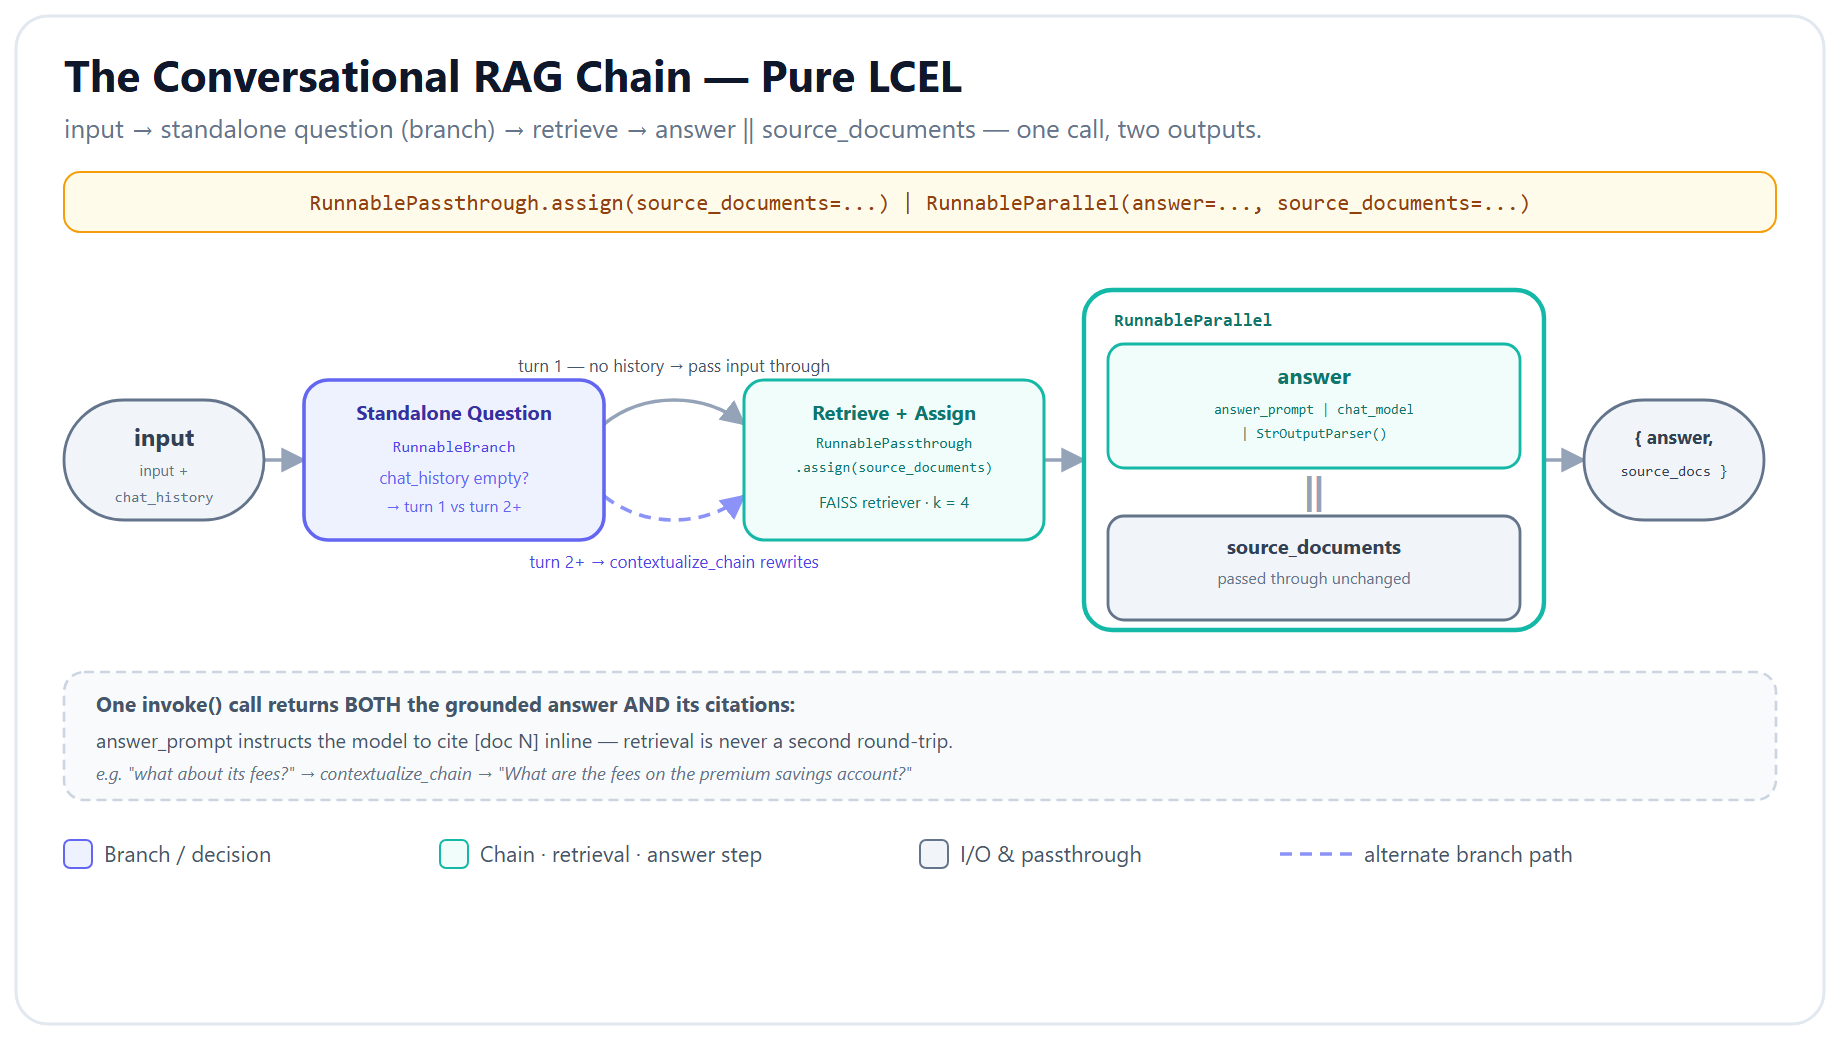

**Figure — The conversational RAG chain (pure LCEL).** A `RunnableBranch` reformulates follow-ups into standalone questions (skipping the first turn), retrieval runs, and a `RunnableParallel` returns the grounded answer alongside its source documents and `[doc N]` citations.

In [6]:
def format_docs(documents):
    """Render retrieved documents as a numbered context block the model can cite as [doc N]."""
    return "\n\n".join(
        f"[doc {index}] (Source: {get_doc_signature(document)})\n{document.page_content}"
        for index, document in enumerate(documents, start=1)
    )

# 1. Only reformulate when there IS history (saves an LLM call on the first turn).
standalone_question = RunnableBranch(
    (lambda inputs: not inputs.get("chat_history"), lambda inputs: inputs["input"]),
    contextualize_chain,
)

# 2. Standalone question → retrieved documents.
retrieve_documents = standalone_question | retriever

# 3. Answer + sources in parallel.
conversational_rag_chain = (
    RunnablePassthrough.assign(source_documents=retrieve_documents)
    | RunnableParallel(
        answer=(
            RunnablePassthrough.assign(context=lambda inputs: format_docs(inputs["source_documents"]))
            | answer_prompt | chat_model | StrOutputParser()
        ),
        source_documents=lambda inputs: inputs["source_documents"],
    )
)
print("✅ Conversational RAG chain ready (contextualize → retrieve → answer ‖ sources)")

✅ Conversational RAG chain ready (contextualize → retrieve → answer ‖ sources)


## 7. Per-user memory & threads — one message list per user

Memory takes four steps on every call: **load** this user's history, **inject** it into the
`chat_history` placeholder, **run** the chain, then **append** the new question and answer to that
history. `ask_question` does exactly that, keyed by **`user_id`**, so every user gets a private,
isolated thread.

We keep the histories in a simple dict (`conversation_store`) of plain message lists — that's what
we'll compress in Part B and serialize in Part D.

> **Why not `RunnableWithMessageHistory`?** It automates the same four steps, but it keeps each history
> in a chat-history object — and `BaseChatMessageHistory` / `InMemoryChatMessageHistory` are deprecated
> from langchain-core 1.6.4. Four explicit lines do the same job and hide nothing. Inside an agent, the
> same idea is a LangGraph **checkpointer** keyed by `thread_id` — Lab 7.2.

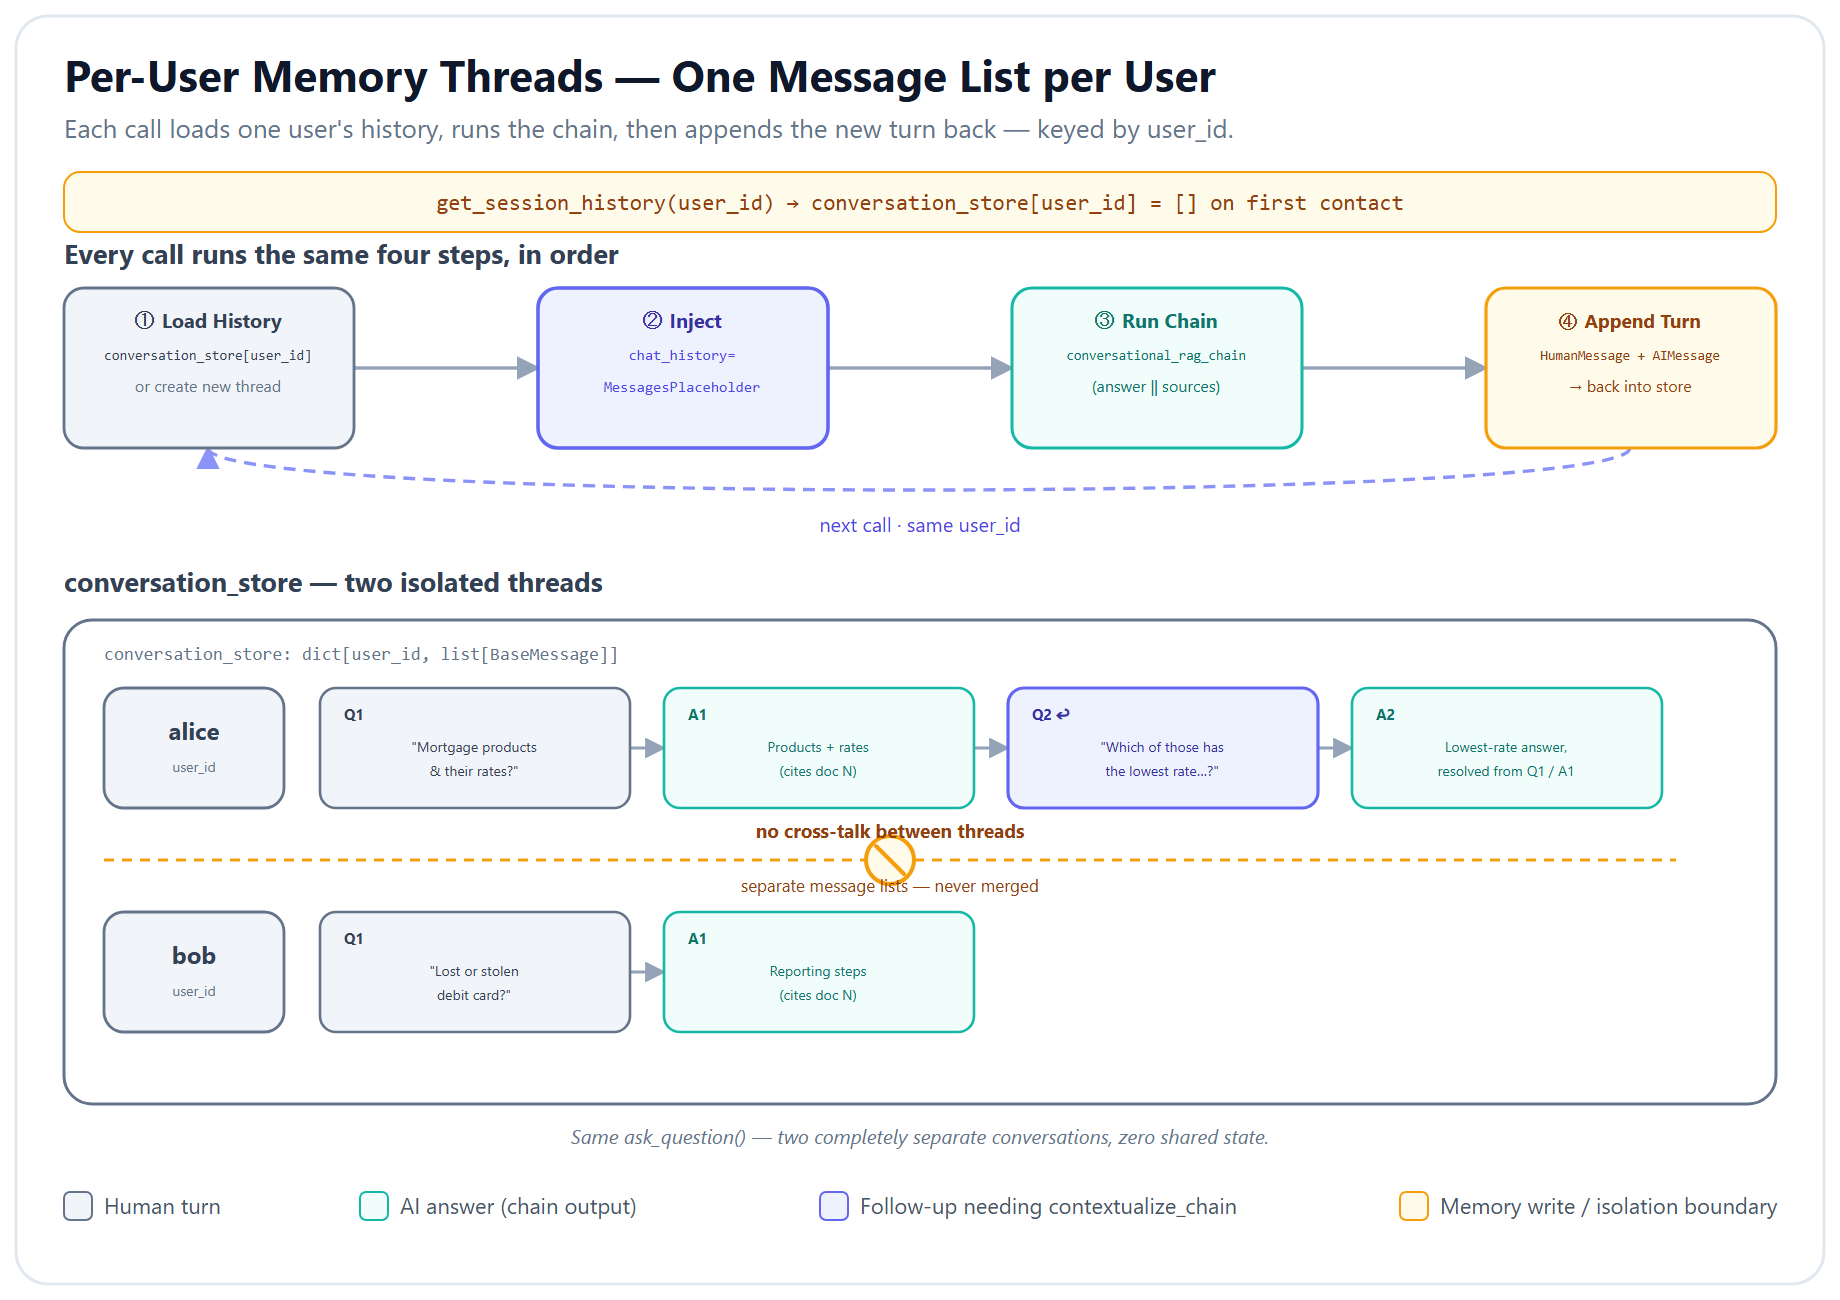

**Figure — Per-user memory threads.** `ask_question` keeps one message list per `user_id`, loading it into the prompt and appending every new turn — so alice's follow-ups resolve from her thread while bob's stays completely isolated.

In [7]:
conversation_store = {}   # user_id -> list of messages (the raw thread)
turns_log = {}            # user_id -> list of {"query", "answer", "citations"} (for persistence + audit)

def get_session_history(user_id):
    """Return the running message list for one user, creating an empty thread on first contact."""
    if user_id not in conversation_store:
        conversation_store[user_id] = []
    return conversation_store[user_id]

def ask_question(user_id, question, show_sources=True):
    """Ask `question` as `user_id`, print the grounded answer + citations, and log the turn."""
    chat_history = get_session_history(user_id)                      # 1. load this user's thread
    result = conversational_rag_chain.invoke(                         # 2. inject it + 3. run the chain
        {"input": question, "chat_history": chat_history}
    )
    answer = result["answer"]
    chat_history.extend([HumanMessage(content=question), AIMessage(content=answer)])  # 4. append
    source_documents = result["source_documents"]
    citations = [get_doc_signature(document) for document in source_documents]
    turns_log.setdefault(user_id, []).append(
        {"query": question, "answer": answer, "citations": citations}
    )
    print(f"👤 [{user_id}] {question}")
    print(f"🤖 {answer}\n")
    if show_sources:
        show_hits(source_documents, "sources the answer could cite")
    print("─" * 84)
    return result

print("✅ Per-user conversational memory wired (one message list per user_id)")

✅ Per-user conversational memory wired (one message list per user_id)


## 8. Demo — separate threads, and a follow-up that needs memory

Two users ask unrelated questions, then **alice** asks a **follow-up**. The word *"those"* has no
meaning on its own — it only resolves because alice's earlier turn is in her thread and the
contextualize step rewrites it into a standalone query. **bob**'s thread is never consulted.

In [8]:
# Two independent users → two isolated threads
ask_question("alice", "What mortgage products do you offer, and what are their rates?")
ask_question("bob", "How do I report a lost or stolen debit card?")

# alice's FOLLOW-UP — "those" refers to her mortgages, resolved from HER history only
ask_question("alice", "Which of those has the lowest rate, and what credit score does it need?")

print("🧵 alice's thread has", len(conversation_store["alice"]), "messages;",
      "bob's thread has", len(conversation_store["bob"]), "messages — fully isolated.")

👤 [alice] What mortgage products do you offer, and what are their rates?
🤖 We offer several mortgage products with the following rates:

1. Conventional Mortgages: 30-year fixed at 6.5% APR. Requires minimum credit score 620, 20% down payment or PMI, max ratio 43%, loan limit 726,200 [doc 1].

2. FHA Loans: Rate 6.25% APR. Down payment as low as 3.5% with 580 credit score, upfront and annual mortgage insurance premiums apply [doc 1].

3. VA Loans: Rate 6.0% APR. No down payment or mortgage insurance for eligible veterans, but a 2.3% funding fee applies [doc 1].

4. HELOC: Prime rate plus 1.5%. Draw period 10 years, repayment 20 years, minimum line 25,000, max 80% combined LTV [doc 1].

5. Retail Home Loan: Secured against property, rate from 8.4%, credit score 650+, LTV up to 80% (90% for first-time buyers) [doc 2].

— sources the answer could cite —
  1. [Mortgage Lending] # Mortgage Lending Policy  (Policy Ref: POL-MTG-2024-03)

## Conventio…
  2. [Retail Loans] # Retail Loan Product

👤 [bob] How do I report a lost or stolen debit card?
🤖 To report a lost or stolen debit card, you should call the fraud hotline at 1-800-BANK-911. This hotline is available 24x7 for such reports [doc 1][doc 3].

— sources the answer could cite —
  1. [Fraud Security] # Fraud Prevention & Account Security  (Policy Ref: POL-SEC-2024-06)…
  2. [Credit Cards] # Credit Card Products  (Policy Ref: POL-CC-2024-05)

## Premium Rewar…
  3. [Service Codes Reference] ## Net-Banking Error Codes
- NB-2200 — session expired; re-login requi…
  4. [Service Codes Reference] # Service Request & Error Code Reference  (Policy Ref: POL-SRV-2024-08…
────────────────────────────────────────────────────────────────────────────────────


👤 [alice] Which of those has the lowest rate, and what credit score does it need?
🤖 The mortgage product with the lowest rate is the VA Loan at 6.0% APR. It does not specify a minimum credit score requirement but is available to eligible veterans [doc 1]. Among products with stated credit scores, FHA Loans have a rate of 6.25% APR and require a minimum credit score of 580 [doc 1].

— sources the answer could cite —
  1. [Mortgage Lending] # Mortgage Lending Policy  (Policy Ref: POL-MTG-2024-03)

## Conventio…
  2. [Retail Loans] # Retail Loan Products  (Policy Ref: POL-RTL-2024-07)

## Personal Loa…
  3. [Commercial Lending] # Commercial Lending Policy  (Policy Ref: POL-COM-2024-01)

## Term Lo…
  4. [Credit Cards] # Credit Card Products  (Policy Ref: POL-CC-2024-05)

## Premium Rewar…
────────────────────────────────────────────────────────────────────────────────────
🧵 alice's thread has 4 messages; bob's thread has 2 messages — fully isolated.


---
# Part B — Compressing the conversation history

Notice what `ask_question` sends to the model each turn: the **entire** history, every
time. Token count — and therefore **cost, latency, and context-window pressure** — grows with every
message. Compression trims *what the model sees* while (optionally) keeping the full record on disk.

## 9. Watch the history grow

We build an illustrative multi-turn banking conversation as an explicit message list (no API calls
needed to make the point) and estimate its size. Imagine this is turn 6 of a long support chat.

In [9]:
from langchain_core.messages import HumanMessage, AIMessage

def estimate_token_count(messages):
    """Roughly estimate the token count of a message list (~4 characters per token)."""
    return sum(len(message.content) for message in messages) // 4

demo_history = [
    SystemMessage(content="You are a banking-policy assistant."),
    HumanMessage(content="What is the interest rate on the premium savings account?"),
    AIMessage(content="The premium savings account earns 4.5% APY with no minimum balance [doc 1]."),
    HumanMessage(content="How is that interest compounded and credited?"),
    AIMessage(content="Interest is compounded daily and credited to your account monthly [doc 2]."),
    HumanMessage(content="What credit cards have no annual fee?"),
    AIMessage(content="The Student and Cashback cards have no annual fee; the Premium card waives it year one [doc 3]."),
    HumanMessage(content="What is the APR on the Cashback card?"),
    AIMessage(content="The Cashback card's purchase APR is 19.99% variable [doc 4]."),
    HumanMessage(content="And what is the late payment fee on it?"),
    AIMessage(content="The late payment fee on the Cashback card is $35 [doc 5]."),
]

print(f"Full history: {len(demo_history)} messages ≈ {estimate_token_count(demo_history)} tokens")
print("Every turn resends all of this — the bill grows linearly with the conversation.")

Full history: 11 messages ≈ 152 tokens
Every turn resends all of this — the bill grows linearly with the conversation.


## 10. Five compression strategies

Each strategy below is a small, transparent function that takes a message list and returns a
**shorter** message list to feed the prompt. The classic LangChain memory classes are named in the
table, but they are **deprecated** — we implement the *ideas* with the current core `trim_messages`
and LCEL summary chains instead.

| Strategy | Classic class (deprecated) | Keeps | Trade-off |
|---|---|---|---|
| **Full buffer** | `ConversationBufferMemory` | every turn verbatim | max fidelity; tokens grow **unbounded** |
| **Window (K turns)** | `ConversationBufferWindowMemory` | last **K** exchanges | bounded; **drops** older context |
| **Token budget** | `ConversationTokenBufferMemory` | recent turns fitting a **token cap** | bounds prompt size directly |
| **Summary** | `ConversationSummaryMemory` | a rolling **LLM summary** | compact; loses verbatim detail; +1 LLM call |
| **Summary + buffer** | `ConversationSummaryBufferMemory` | summary of old **+** recent verbatim | production sweet spot |

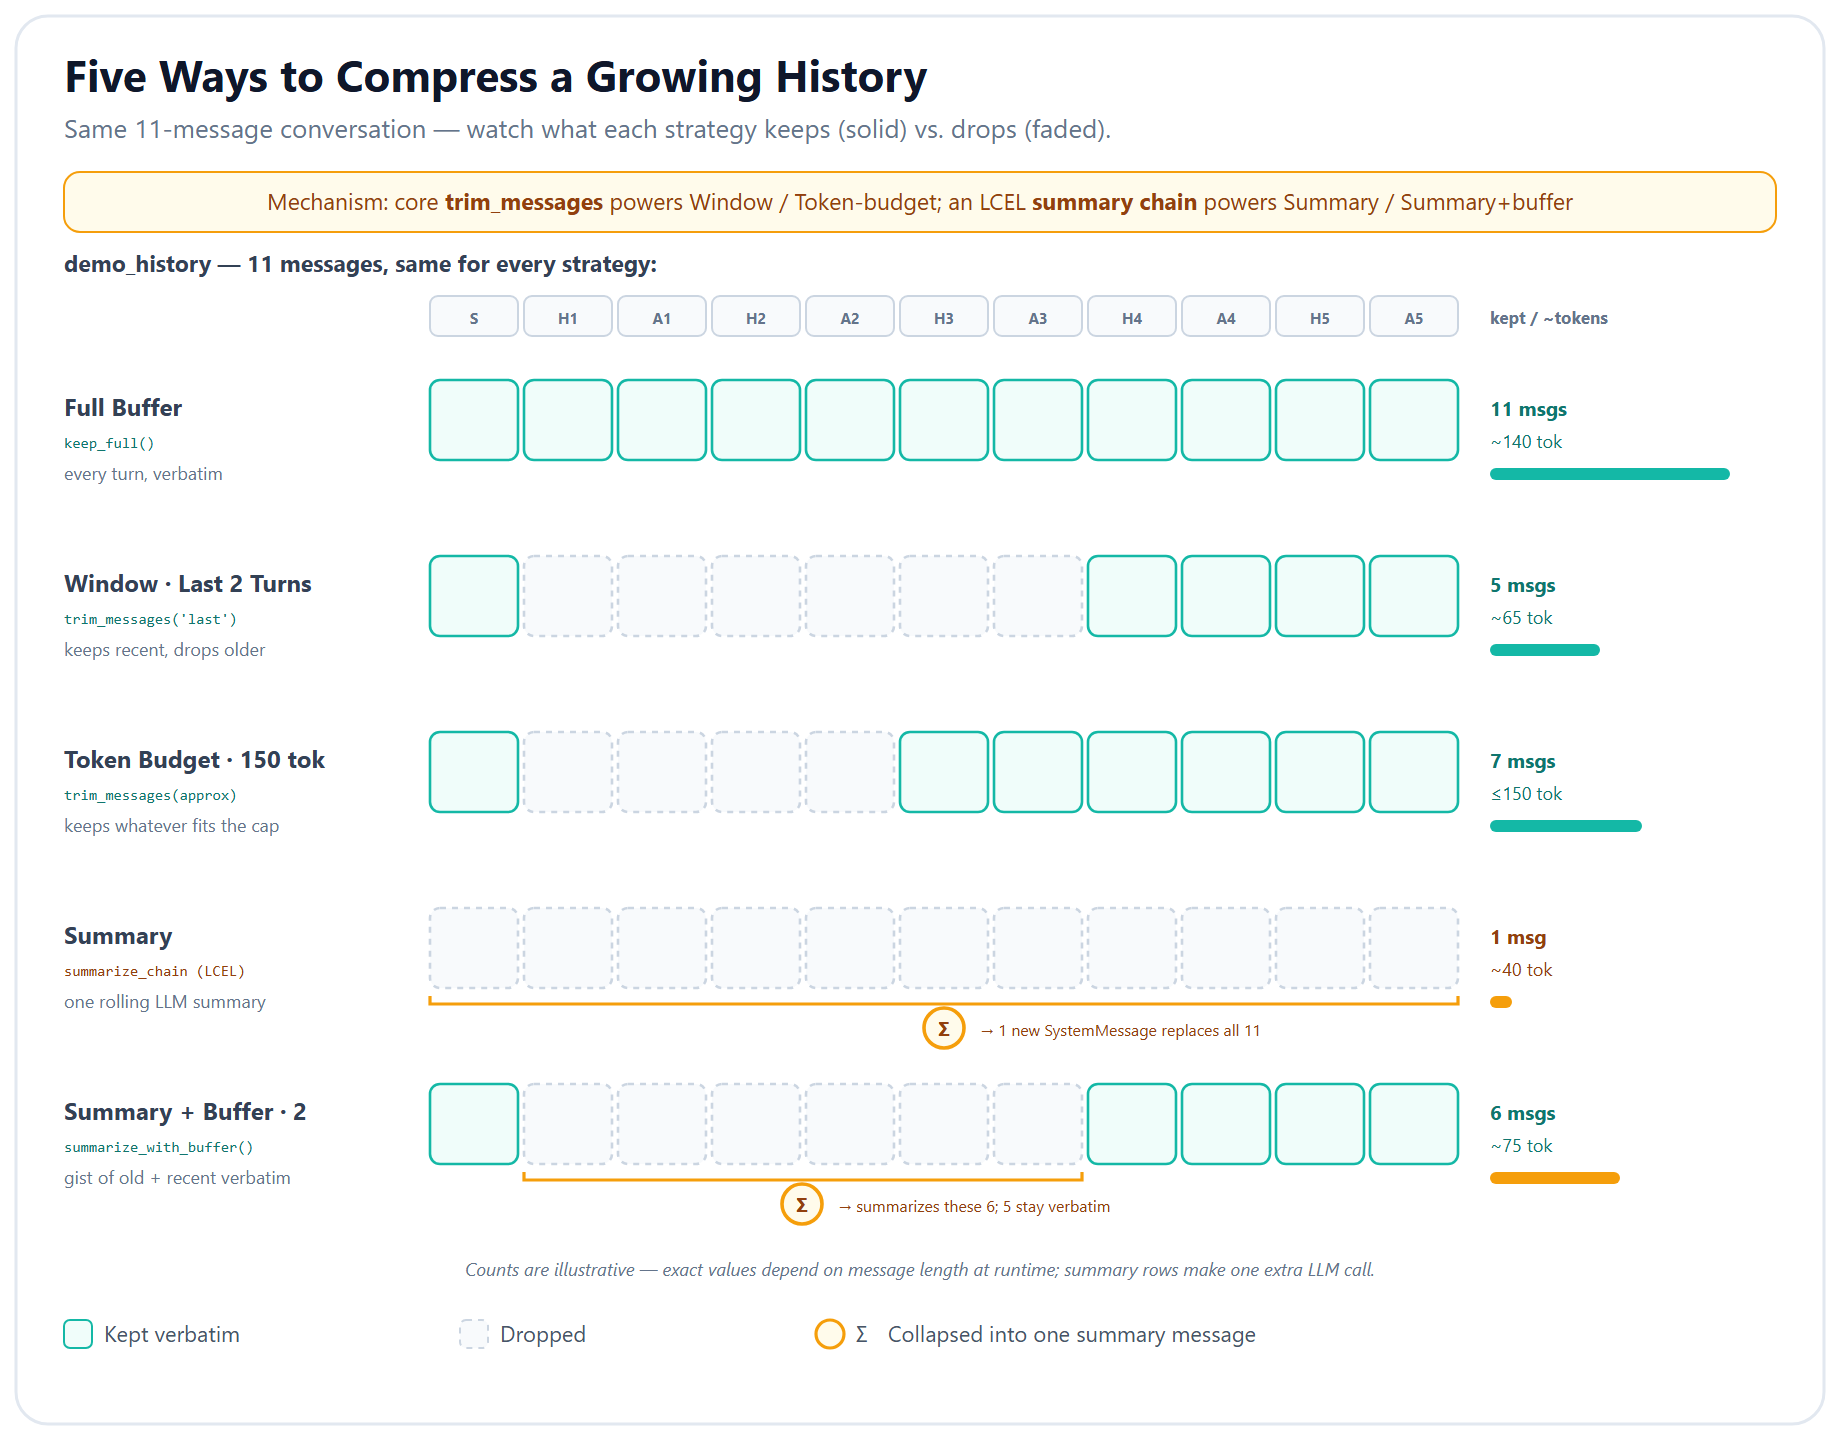

**Figure — Five ways to compress a growing history.** Full buffer keeps everything (unbounded), Window / Token-budget keep recent turns (via core `trim_messages`), Summary keeps a rolling LLM gist, and Summary + buffer keeps both — the production sweet spot.

In [10]:
def render_messages(messages):
    """Render a message list as plain 'Role: text' lines for a summarizer prompt."""
    role_labels = {"human": "User", "ai": "Assistant", "system": "System"}
    return "\n".join(f"{role_labels.get(message.type, message.type)}: {message.content}" for message in messages)

# One LCEL summary chain, reused by both summary strategies.
summarize_prompt = ChatPromptTemplate.from_messages([
    ("system", "You compress a conversation into a compact factual summary that preserves the user's "
               "intent, the key entities, any decisions, and every figure mentioned. "
               "Write 2-4 sentences in the third person."),
    ("human", "Summarize this conversation:\n\n{conversation}"),
])
summarize_chain = summarize_prompt | chat_model | StrOutputParser()


def keep_full(messages):
    """No compression — keep the entire history verbatim (the ConversationBufferMemory idea)."""
    return messages


def keep_last_turns(messages, keep_turns=2):
    """Keep only the most recent `keep_turns` exchanges (the ConversationBufferWindowMemory idea)."""
    return trim_messages(
        messages, strategy="last", token_counter=len,   # token_counter=len counts MESSAGES
        max_tokens=keep_turns * 2, include_system=True, start_on="human",
    )


def keep_token_budget(messages, max_tokens=150):
    """Keep the most recent turns that fit a token budget (the ConversationTokenBufferMemory idea)."""
    return trim_messages(
        messages, strategy="last", token_counter="approximate",   # fast heuristic token counter
        max_tokens=max_tokens, include_system=True, start_on="human",
    )


def summarize_history(messages):
    """Replace the whole history with one rolling LLM summary (the ConversationSummaryMemory idea)."""
    dialogue = [message for message in messages if not isinstance(message, SystemMessage)]
    summary_text = summarize_chain.invoke({"conversation": render_messages(dialogue)})
    return [SystemMessage(content=f"Summary of earlier conversation: {summary_text}")]


def summarize_with_buffer(messages, keep_turns=2):
    """Summarize older turns, keep the recent `keep_turns` verbatim (the ConversationSummaryBufferMemory idea)."""
    system_messages = [message for message in messages if isinstance(message, SystemMessage)]
    dialogue = [message for message in messages if not isinstance(message, SystemMessage)]
    recent = dialogue[-keep_turns * 2:]
    older = dialogue[: len(dialogue) - len(recent)]
    if not older:
        return messages
    summary_text = summarize_chain.invoke({"conversation": render_messages(older)})
    summary_message = SystemMessage(content=f"Summary of earlier turns: {summary_text}")
    return system_messages + [summary_message] + recent

print("✅ Five compressors defined")

✅ Five compressors defined


## 11. Compare them on the same conversation

Same 11-message history, five strategies, side by side — watch the message count fall. (The two
summary strategies each make one LLM call to compress.)

> **Read the token column too.** This demo history is short (about 150 tokens), so an LLM summary
> of it can come out *longer* than the turns it replaces. Summaries pay off once a history is long;
> on a short one, a window is cheaper and loses nothing.

In [11]:
compression_strategies = [
    ("Full buffer",            lambda messages: keep_full(messages)),
    ("Window · last 2 turns",  lambda messages: keep_last_turns(messages, keep_turns=2)),
    ("Token budget · 150 tok", lambda messages: keep_token_budget(messages, max_tokens=150)),
    ("Summary",                lambda messages: summarize_history(messages)),
    ("Summary + buffer · 2",   lambda messages: summarize_with_buffer(messages, keep_turns=2)),
]

print(f"{'Strategy':<26}{'Messages':>10}{'~Tokens':>10}")
print("-" * 46)
for strategy_name, compressor in compression_strategies:
    compressed_messages = compressor(demo_history)
    print(f"{strategy_name:<26}{len(compressed_messages):>10}{estimate_token_count(compressed_messages):>10}")

print("\n👉 Window/token-budget drop old turns; summary keeps the gist; summary+buffer keeps both.")

Strategy                    Messages   ~Tokens
----------------------------------------------
Full buffer                       11       152
Window · last 2 turns              3        32
Token budget · 150 tok             7        90


Summary                            1       108


Summary + buffer · 2               6       165

👉 Window/token-budget drop old turns; summary keeps the gist; summary+buffer keeps both.


### Wiring a compressor into the live chain
To apply compression to the *running* assistant, insert the compressor as a **pre-prompt step** so
only the compressed view reaches the model, while `conversation_store` keeps the full thread:

```python
compressed_history_chain = RunnablePassthrough.assign(
    chat_history=lambda inputs: keep_last_turns(inputs["chat_history"], keep_turns=3)
) | conversational_rag_chain
```
The full history still lives in `conversation_store` (and gets persisted in Part D); the model just
sees a bounded slice.

## 12. Decision matrix — what to use when

| Situation | Use | Why |
|---|---|---|
| Short chat (≲ 6 turns) | **Full buffer** | nothing lost, cheap enough |
| Long chat, only recent turns matter | **Window (K)** | bounded; preserves the follow-up context |
| Hard token / cost ceiling | **Token budget** | caps prompt size directly |
| Long chat, only the *gist* of old turns matters | **Summary** | compact; tolerates detail loss |
| Long chat needing recent detail **+** old gist | **Summary + buffer** | best fidelity/size balance — the default |
| You resend a big stable prefix each turn | **+ prompt caching (Part C)** | cuts cost of the unchanged prefix under any strategy |

**Rule of thumb:** start with **summary + buffer** for long-lived assistants; drop to **window** when
you want zero extra LLM calls; use **token budget** when a provider/cost limit is the hard constraint.

> ⏭️ **After the session.** This section is not run live in the workshop. Work through it afterwards, top to bottom.

---
# Part C — Prompt caching (OpenAI)

Compression shrinks the *history*; **caching** cuts the cost of the parts that **repeat**. OpenAI
**automatically** caches long, identical prompt **prefixes** (≥ 1024 tokens): on a cache hit you're
billed less for those tokens and the call is faster. In RAG the natural stable prefix is the
**system prompt + retrieved context**.

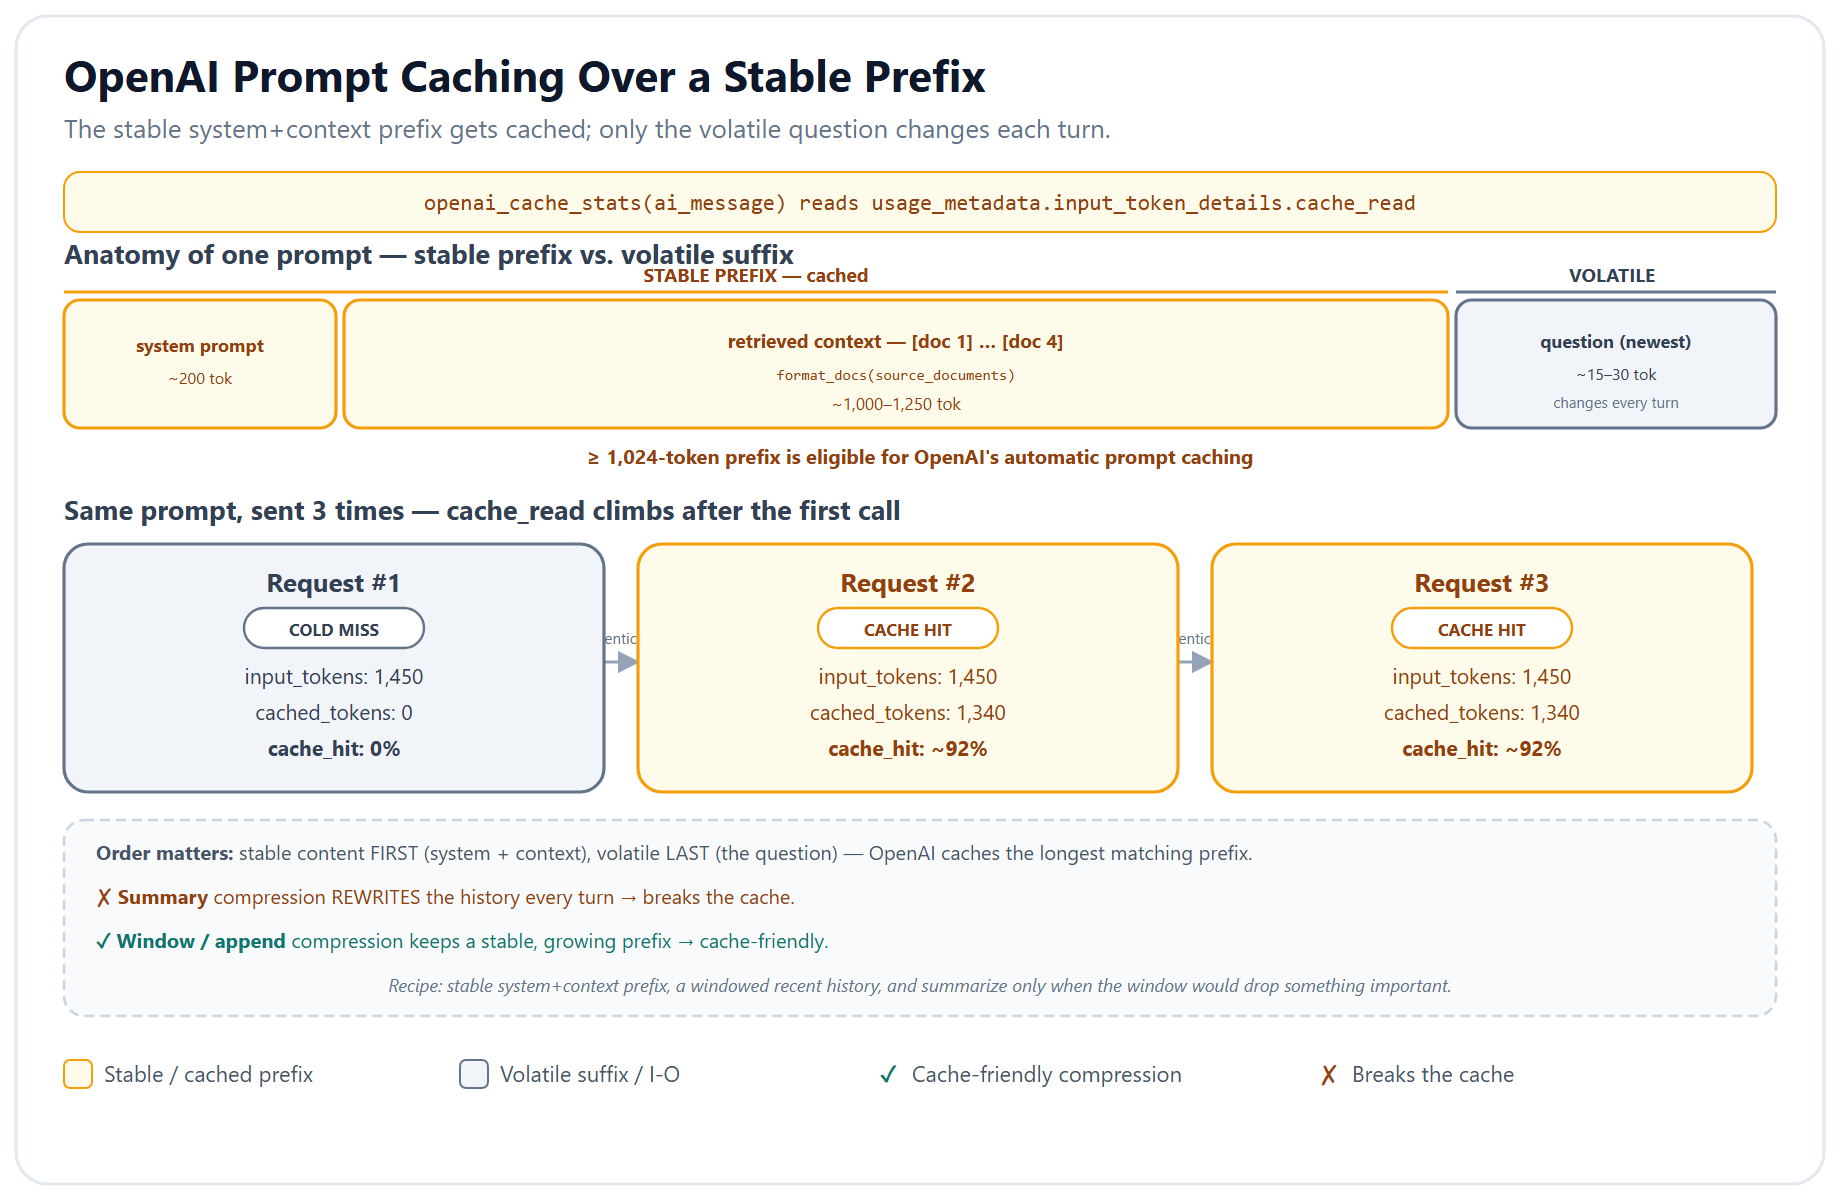

**Figure — OpenAI prompt caching over a stable prefix.** Put the system prompt + retrieved context first (≥ 1024 tokens) and the newest question last; OpenAI cache-reads the unchanged prefix on repeat calls. Summary compression rewrites history and breaks the cache; windowing keeps it intact.

## 13. Watch `cached_tokens` climb

We build one full RAG prompt (system + 4 retrieved chunks — comfortably over the 1024-token cache
threshold) and send the **same** prompt three times. LangChain surfaces OpenAI's cache counters on
each `AIMessage.usage_metadata`; we read them with a small helper (the LangChain-native version of
`openai_cache_stats` from the Module 1 Prompt Caching take-home lab).

In [12]:
def openai_cache_stats(ai_message):
    """Read OpenAI prompt-cache counters from a LangChain AIMessage's usage metadata."""
    usage = ai_message.usage_metadata or {}
    input_tokens = usage.get("input_tokens", 0)
    cached_tokens = usage.get("input_token_details", {}).get("cache_read", 0)
    cache_hit_percent = round(100 * cached_tokens / input_tokens, 1) if input_tokens else 0.0
    return {"input_tokens": input_tokens, "cached_tokens": cached_tokens, "cache_hit_percent": cache_hit_percent}

# Build one sizeable, stable prompt (system + retrieved context) and reuse it verbatim.
caching_question = "What mortgage products are available and what are their rates and terms?"
retrieved_for_caching = retriever.invoke(caching_question)
cached_prompt_messages = answer_prompt.format_messages(
    input=caching_question, context=format_docs(retrieved_for_caching), chat_history=[]
)

print(f"{'Request':<10}{'input_tokens':>14}{'cached_tokens':>15}{'cache_hit':>11}")
print("-" * 50)
for request_number in range(1, 4):
    ai_message = chat_model.invoke(cached_prompt_messages)
    stats = openai_cache_stats(ai_message)
    print(f"#{request_number:<9}{stats['input_tokens']:>14}{stats['cached_tokens']:>15}{str(stats['cache_hit_percent']) + '%':>11}")

print("\n💡 Request #1 is a cold miss; #2–3 should show cached_tokens > 0 once the prefix is cached.")
print("   (OpenAI caching is automatic and best-effort; it activates for prefixes ≥ 1024 tokens.)")

Request     input_tokens  cached_tokens  cache_hit
--------------------------------------------------


#1                   984              0       0.0%


#2                   984              0       0.0%


#3                   984              0       0.0%

💡 Request #1 is a cold miss; #2–3 should show cached_tokens > 0 once the prefix is cached.
   (OpenAI caching is automatic and best-effort; it activates for prefixes ≥ 1024 tokens.)


## 14. Caching ↔ compression — the trade-off

Caching rewards a **stable prefix**; compression **changes** the history — so they interact:

- **Summary** compression *rewrites* the history every turn → that portion can't be cache-read.
- **Window / append** keeps a growing-but-**stable** prefix → cache-friendly.
- **Order matters:** put the most stable content **first** (system prompt → retrieved context),
  volatile content **last** (the newest question). OpenAI caches the longest matching *prefix*, so
  anything before the first change still gets cached.

**Practical recipe:** stable system prompt + stable retrieved context as the cached prefix, a
**windowed** recent history, and summary only when the window would drop something important. You get
bounded tokens *and* cheap repeated prefixes.

---
# Part D — Persist & resume conversations

Memory in a dict vanishes when the process exits. To survive restarts we serialize every user's
thread to JSON with `messages_to_dict`, and restore it with `messages_from_dict`. We persist the
**full raw history** (for audit/resume) plus the per-turn log of queries, answers, and citations.

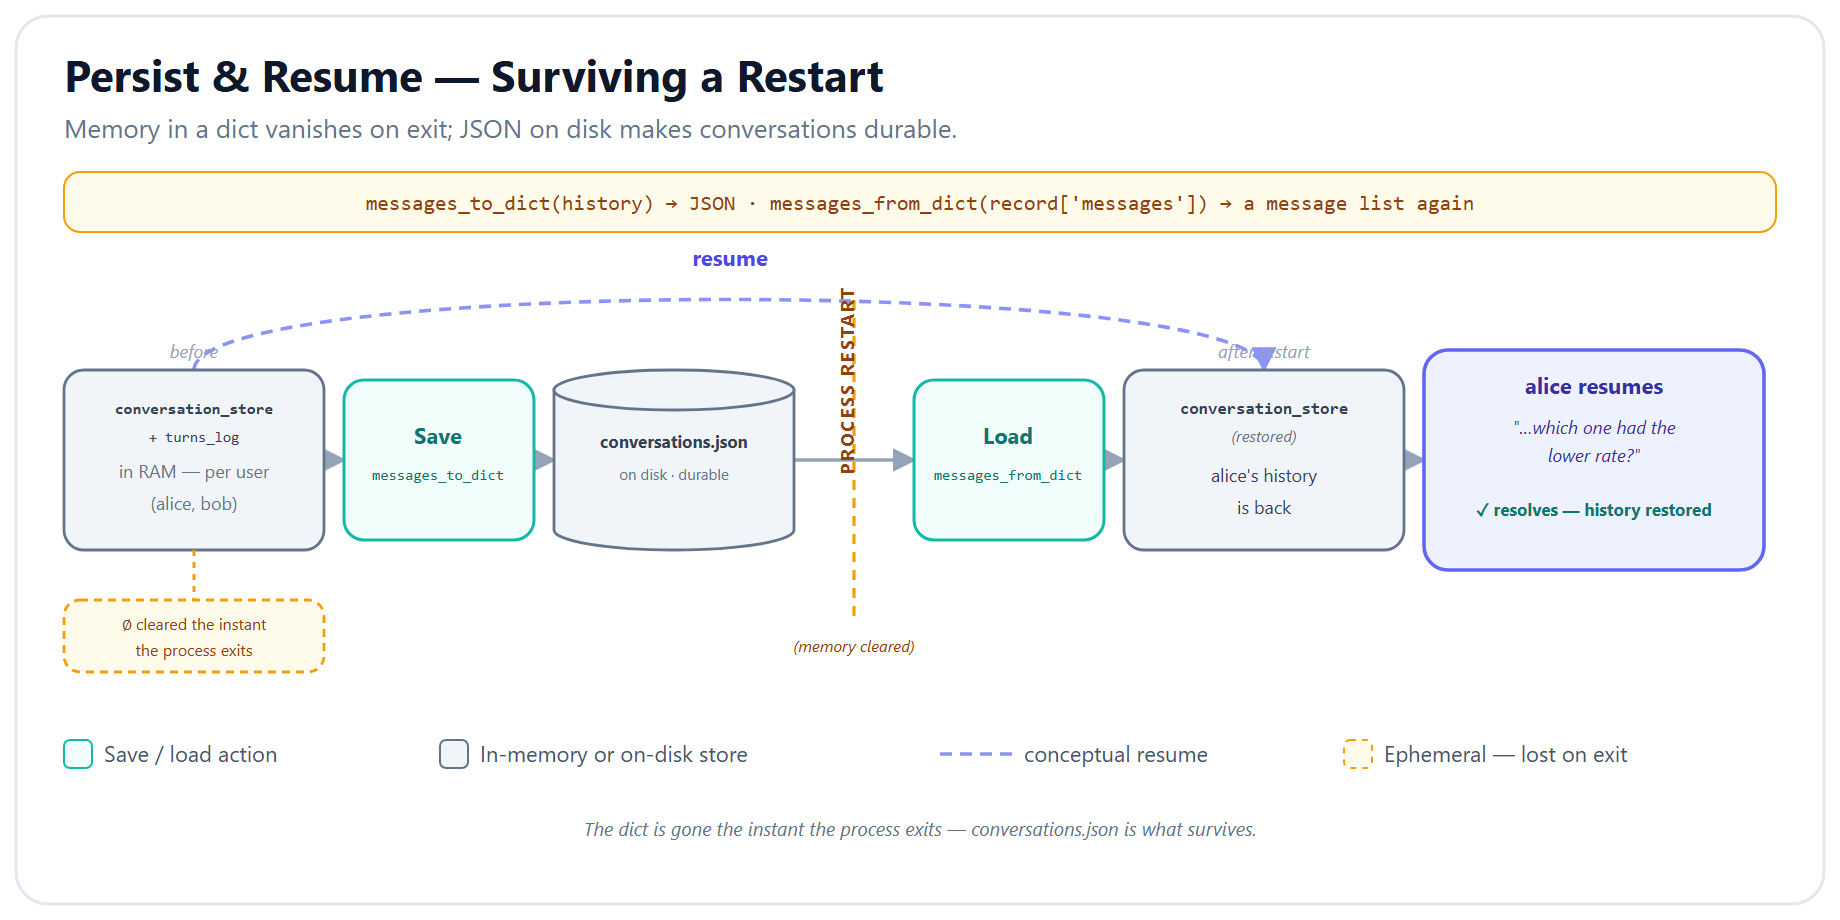

**Figure — Persist & resume.** `messages_to_dict` serializes every user's thread (plus a query/answer/citation log) to `conversations.json`; after a restart, `messages_from_dict` rehydrates it so the conversation genuinely resumes.

## 15. Save every conversation to JSON

In [13]:
def save_conversations(store, turns, file_path="conversations.json"):
    """Persist each user's raw message history + per-turn log (query/answer/citations) to JSON."""
    payload = {}
    for user_id, history in store.items():
        payload[user_id] = {
            "messages": messages_to_dict(history),
            "turns": turns.get(user_id, []),
        }
    with open(file_path, "w", encoding="utf-8") as file_handle:
        json.dump(payload, file_handle, indent=2, ensure_ascii=False)
    print(f"💾 Saved {len(payload)} conversation(s) → {file_path}")
    for user_id, record in payload.items():
        print(f"   {user_id}: {len(record['messages'])} messages, {len(record['turns'])} turns")

save_conversations(conversation_store, turns_log)

# Peek at what alice's persisted turn log looks like (queries + answers + citations)
with open("conversations.json", encoding="utf-8") as file_handle:
    saved_payload = json.load(file_handle)
print("\n🧾 alice's persisted turns (preview):")
print(json.dumps(saved_payload["alice"]["turns"], indent=2, ensure_ascii=False)[:500], "…")

💾 Saved 2 conversation(s) → conversations.json
   alice: 4 messages, 2 turns
   bob: 2 messages, 1 turns

🧾 alice's persisted turns (preview):
[
  {
    "query": "What mortgage products do you offer, and what are their rates?",
    "answer": "We offer several mortgage products with the following rates:\n\n1. Conventional Mortgages: 30-year fixed at 6.5% APR. Requires minimum credit score 620, 20% down payment or PMI, max ratio 43%, loan limit 726,200 [doc 1].\n\n2. FHA Loans: Rate 6.25% APR. Down payment as low as 3.5% with 580 credit score, upfront and annual mortgage insurance premiums apply [doc 1].\n\n3. VA Loans: Rate 6.0% APR. No …


## 16. Load from disk and resume the conversation

We simulate a fresh process: **clear** the in-memory store, **restore** it from JSON, then have alice
ask another follow-up. Because her thread is back, the contextualize step can still resolve
references — the conversation genuinely **resumes**.

In [14]:
def load_conversations(file_path="conversations.json"):
    """Rehydrate the per-user message store and turn log from a JSON file."""
    with open(file_path, encoding="utf-8") as file_handle:
        payload = json.load(file_handle)
    restored_store, restored_turns = {}, {}
    for user_id, record in payload.items():
        restored_store[user_id] = messages_from_dict(record["messages"])
        restored_turns[user_id] = record["turns"]
    return restored_store, restored_turns

# Wipe memory (as if the process restarted), then restore purely from disk.
conversation_store.clear()
turns_log.clear()
restored_store, restored_turns = load_conversations()
conversation_store.update(restored_store)
turns_log.update(restored_turns)
print(f"📂 Restored threads from disk: {list(conversation_store)}")
print(f"   alice is back with {len(conversation_store['alice'])} messages of context.\n")

# Resume: a new follow-up that only makes sense given the restored history
ask_question("alice", "Between those mortgage options, remind me which one you said had the lower rate.")

📂 Restored threads from disk: ['alice', 'bob']
   alice is back with 4 messages of context.



👤 [alice] Between those mortgage options, remind me which one you said had the lower rate.
🤖 The mortgage option with the lowest rate is the VA Loan at 6.0% APR [doc 1].

— sources the answer could cite —
  1. [Mortgage Lending] # Mortgage Lending Policy  (Policy Ref: POL-MTG-2024-03)

## Conventio…
  2. [Mortgage Lending] ## Prepayment (Clause 7.3.2)
Conventional and FHA loans have NO prepay…
  3. [Retail Loans] # Retail Loan Products  (Policy Ref: POL-RTL-2024-07)

## Personal Loa…
  4. [Retail Loans] ## Education Loan
Covers tuition, living expenses, and equipment. Repa…
────────────────────────────────────────────────────────────────────────────────────


{'answer': 'The mortgage option with the lowest rate is the VA Loan at 6.0% APR [doc 1].',
 'source_documents': [Document(id='30c3e185-a608-4da5-af4d-2548f7272309', metadata={'source': 'docs\\mortgage_lending.md', 'title': 'Mortgage Lending'}, page_content='# Mortgage Lending Policy  (Policy Ref: POL-MTG-2024-03)\n\n## Conventional Mortgages\nMinimum credit score 620; 740+ earns the best pricing. Down payment 20%, else\nprivate mortgage insurance (PMI) is required. The maximum permissible ratio is 43%.\nThe 2024 conforming loan limit is 726,200. Rate: 6.5% APR (30-year fixed).\n\n## FHA Loans\nDown payment as low as 3.5% at a 580 score (or 10% down at 500). FHA charges an\nupfront and an annual mortgage insurance premium (MIP). Rate: 6.25% APR.\n\n## VA Loans\nNo down payment and no mortgage insurance for eligible veterans. A 2.3% funding fee\napplies and may be financed. Rate: 6.0% APR.\n\n## HELOC (Home Equity Line of Credit)\nBorrow against home equity at prime rate plus 1.5%. Draw 

## 17. Conclusion & cheat-sheet

| You built | Why it matters |
|---|---|
| Per-user threads (a message list per `user_id`, injected via `MessagesPlaceholder`) | Isolated memory per user, no cross-talk |
| History-aware follow-ups (contextualize chain) | "*what about its fees?*" still retrieves correctly |
| `RunnableParallel` answer + sources + `[doc N]` | Grounded, auditable conversational answers |
| Five compression strategies + decision matrix | Bounded cost/latency as chats grow long |
| OpenAI prompt caching | Cheap repeated prefixes; understood alongside compression |
| JSON persist / resume (`messages_to_dict` / `_from_dict`) | Conversations survive restarts |

**The big picture.** You now have a *stateful*, *bounded*, *cacheable*, *resumable* RAG assistant —
the shape of a real production chatbot. In **Module 6**, an agent will call a retriever like this as
a **tool**, deciding *when* to look things up mid-conversation.

### Try on your own
1. Swap the live chain to use `keep_last_turns(…, 3)` as the pre-prompt step and confirm follow-ups still work.
2. Add an `updated_at` timestamp to each persisted turn and show only "today's" turns on resume.
3. Trigger `summarize_with_buffer` automatically once a thread passes N tokens (`estimate_token_count`).
4. Give each user a `profile` (name, risk appetite) injected into the system prompt as stable, cacheable context.

---
**Next →** this module's take-home lab, **Advanced Retrieval Strategies** (hybrid search, HyDE, re-ranking); then **Module 5 — AI Agents** on Day 2, and in Module 6 a retriever becomes a *tool* an agent chooses to call.